### import libraries

In [352]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_boston

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.linear_model import LinearRegression

### Data gathering

In [353]:
data=load_boston()
data.DESCR

".. _boston_dataset:\n\nBoston house prices dataset\n---------------------------\n\n**Data Set Characteristics:**  \n\n    :Number of Instances: 506 \n\n    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.\n\n    :Attribute Information (in order):\n        - CRIM     per capita crime rate by town\n        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.\n        - INDUS    proportion of non-retail business acres per town\n        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)\n        - NOX      nitric oxides concentration (parts per 10 million)\n        - RM       average number of rooms per dwelling\n        - AGE      proportion of owner-occupied units built prior to 1940\n        - DIS      weighted distances to five Boston employment centres\n        - RAD      index of accessibility to radial highways\n        - TAX      full-value property-tax rate per $10,000

In [354]:
df=pd.DataFrame(data.data,columns=data.feature_names)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [355]:
df['house_price']=data.target
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,house_price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


### EDA

In [356]:
df.shape

(506, 14)

In [357]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'house_price'],
      dtype='object')

In [358]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   CRIM         506 non-null    float64
 1   ZN           506 non-null    float64
 2   INDUS        506 non-null    float64
 3   CHAS         506 non-null    float64
 4   NOX          506 non-null    float64
 5   RM           506 non-null    float64
 6   AGE          506 non-null    float64
 7   DIS          506 non-null    float64
 8   RAD          506 non-null    float64
 9   TAX          506 non-null    float64
 10  PTRATIO      506 non-null    float64
 11  B            506 non-null    float64
 12  LSTAT        506 non-null    float64
 13  house_price  506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [359]:
df.isnull().sum()

CRIM           0
ZN             0
INDUS          0
CHAS           0
NOX            0
RM             0
AGE            0
DIS            0
RAD            0
TAX            0
PTRATIO        0
B              0
LSTAT          0
house_price    0
dtype: int64

In [360]:
df.value_counts().sum()

506

In [361]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,house_price
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [362]:
df.corr()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,house_price
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
ZN,-0.200469,1.000000,-0.533828,-0.042697,-0.516604,0.311991,-0.569537,0.664408,-0.311948,-0.314563,-0.391679,0.175520,-0.412995,0.360445
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
RM,-0.219247,0.311991,-0.391676,0.091251,-0.302188,1.000000,-0.240265,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.613808,0.695360
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536


<AxesSubplot:>

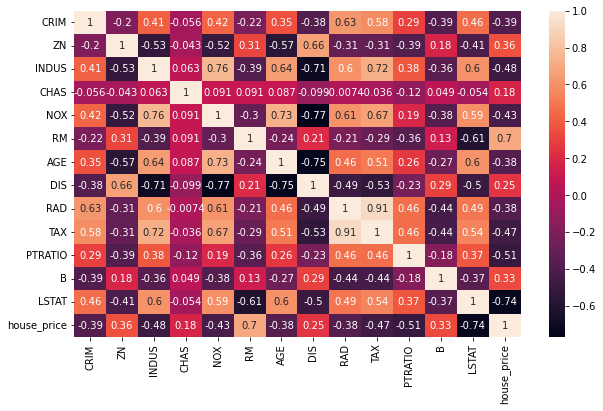

In [363]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)

### outliers detection

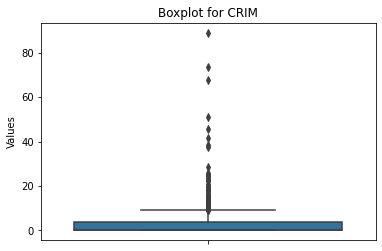

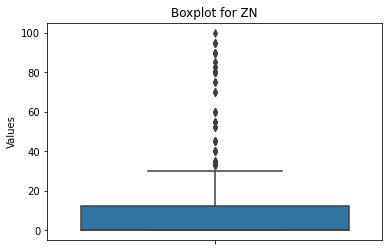

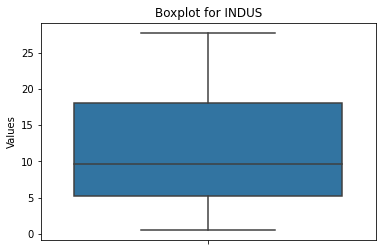

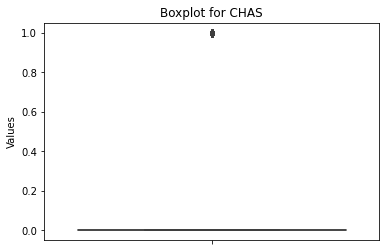

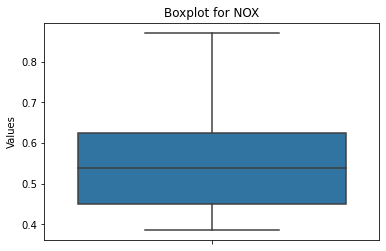

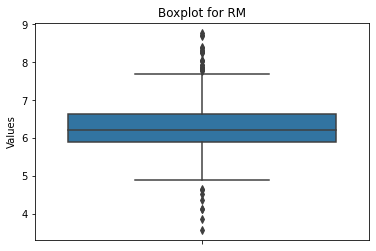

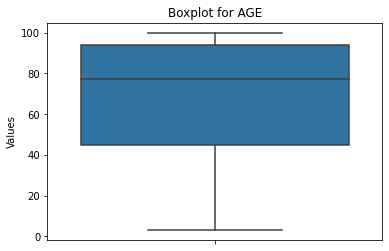

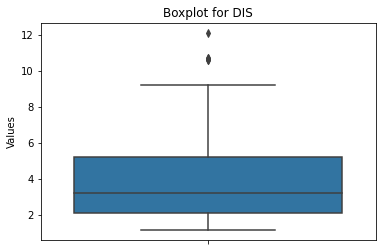

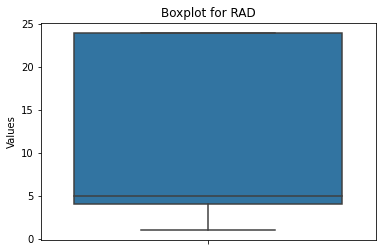

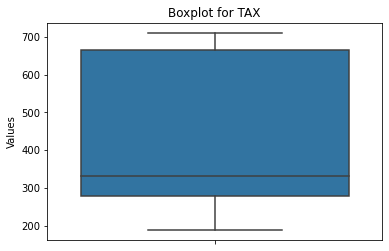

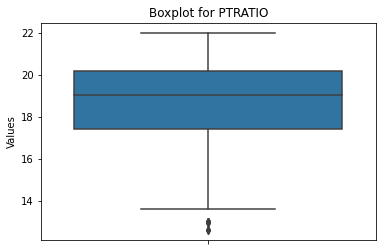

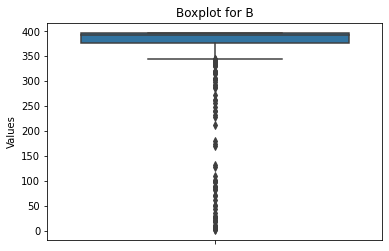

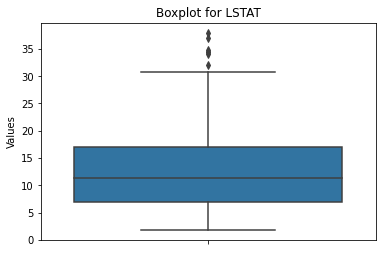

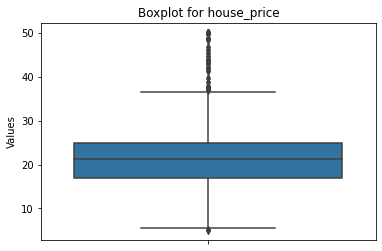

In [364]:
col=df.select_dtypes(include='float64').columns
for i in col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[i])
    plt.title(f'Boxplot for {i}')
    plt.ylabel('Values')
    plt.show()

    

In [365]:
def remove_out(df):
    col=df.select_dtypes(include='float64').columns
    for i in col:
        per25th=df[i].quantile(0.25)
        per75th=df[i].quantile(0.75)
        iqr=per75th-per25th
        max_val=per75th+1.5*iqr
        min_val=per25th-1.5*iqr
        df = df[(df[i] <= max_val) & (df[i] >= min_val)]
    
    return df


In [366]:
df=remove_out(df)


In [367]:
df.shape

(214, 14)

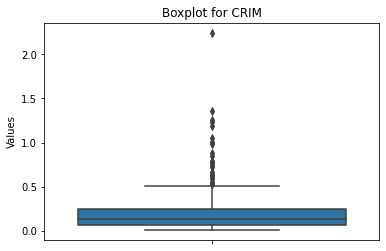

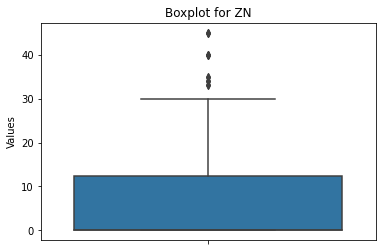

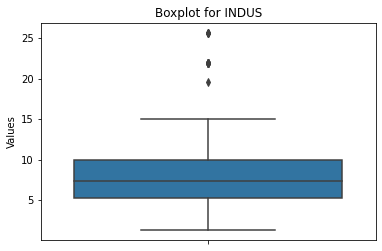

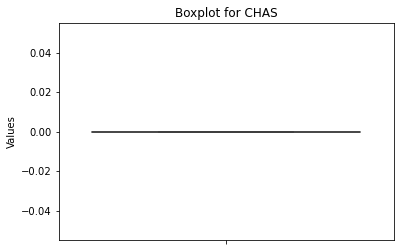

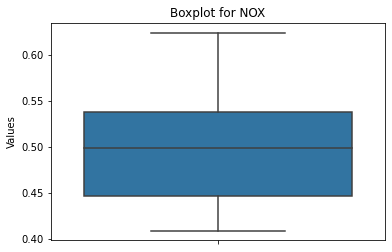

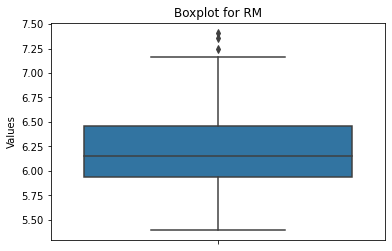

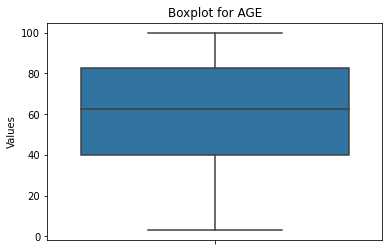

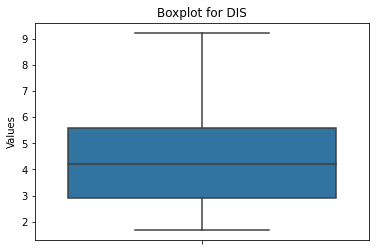

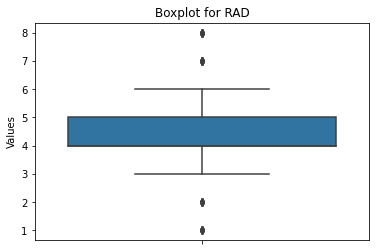

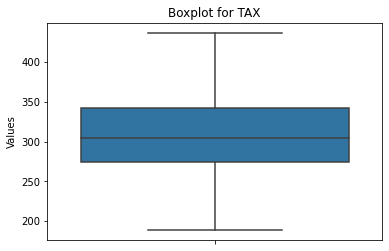

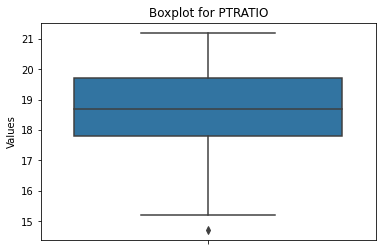

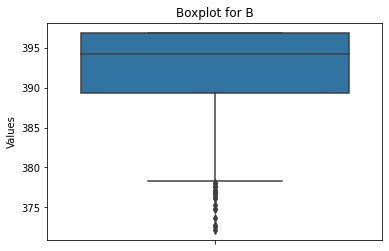

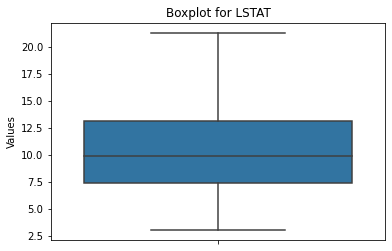

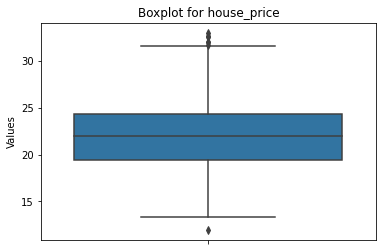

In [368]:
col=df.select_dtypes(include='float64').columns
for i in col:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[i])
    plt.title(f'Boxplot for {i}')
    plt.ylabel('Values')
    plt.show()

### Univariate analysis

#### 1.CRIM

In [369]:
df['CRIM'].head(20)
df['CRIM'].tail(20)

339    0.05497
340    0.06151
341    0.01301
342    0.02498
345    0.03113
349    0.02899
350    0.06211
493    0.17331
494    0.27957
495    0.17899
496    0.28960
497    0.26838
498    0.23912
499    0.17783
500    0.22438
501    0.06263
502    0.04527
503    0.06076
504    0.10959
505    0.04741
Name: CRIM, dtype: float64

<AxesSubplot:xlabel='CRIM', ylabel='Density'>

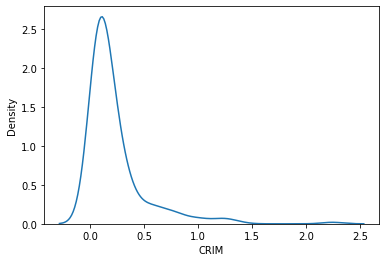

In [370]:
sns.kdeplot(df['CRIM'])

In [371]:
#right skewed so applying log transformation

<AxesSubplot:xlabel='CRIM', ylabel='Density'>

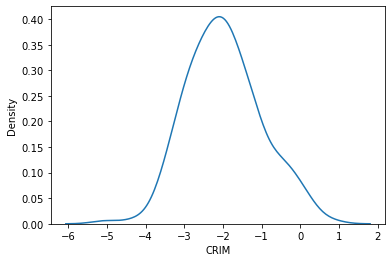

In [372]:
sns.kdeplot(np.log(df['CRIM']))

#### 2.ZN

In [373]:
df['ZN']=df['ZN'].replace({0.0:np.nan})
df['ZN'].isnull().sum()

155

In [374]:
df=df.replace(0.0,np.nan)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,house_price
0,0.00632,18.0,2.31,NaN,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,NaN,7.07,NaN,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
5,0.02985,NaN,2.18,NaN,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,NaN,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,12.5,7.87,NaN,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1


In [375]:
df.isnull().sum()

CRIM             0
ZN             155
INDUS            0
CHAS           214
NOX              0
RM               0
AGE              0
DIS              0
RAD              0
TAX              0
PTRATIO          0
B                0
LSTAT            0
house_price      0
dtype: int64

In [376]:
me=df.isnull().mean()
me

CRIM           0.000000
ZN             0.724299
INDUS          0.000000
CHAS           1.000000
NOX            0.000000
RM             0.000000
AGE            0.000000
DIS            0.000000
RAD            0.000000
TAX            0.000000
PTRATIO        0.000000
B              0.000000
LSTAT          0.000000
house_price    0.000000
dtype: float64

In [377]:
col_to_drop=me[me>0.7].index
col_to_drop

Index(['ZN', 'CHAS'], dtype='object')

In [378]:
me[me>0.7]

ZN      0.724299
CHAS    1.000000
dtype: float64

In [379]:
#droping columns which has null values more than 70%

In [380]:
df=df.drop(columns=col_to_drop,axis=1)
df

,CRIM,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,house_price
0,0.00632,2.31,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,7.07,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
5,0.02985,2.18,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,7.87,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9
7,0.14455,7.87,0.524,6.172,96.1,5.9505,5.0,311.0,15.2,396.90,19.15,27.1
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,11.93,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,11.93,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,11.93,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,11.93,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


### 3.INDUS

<AxesSubplot:ylabel='Density'>

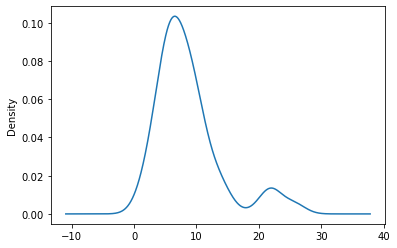

In [381]:
df['INDUS'].plot(kind='kde')

<AxesSubplot:xlabel='INDUS', ylabel='Density'>

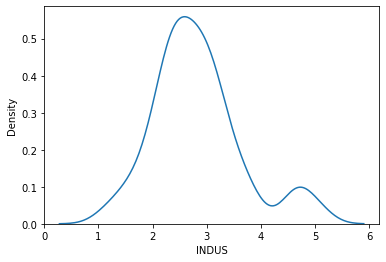

In [382]:
sns.kdeplot(np.sqrt(df['INDUS']))

### 4.NOX	

<AxesSubplot:xlabel='NOX', ylabel='Density'>

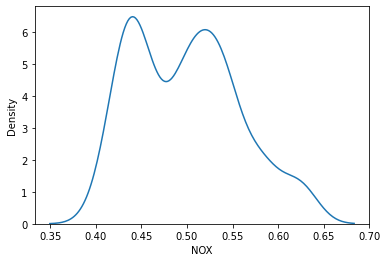

In [383]:
sns.kdeplot(df['NOX'])

<AxesSubplot:xlabel='NOX', ylabel='Density'>

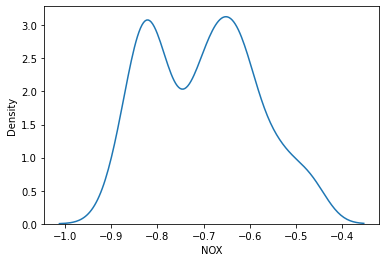

In [384]:
sns.kdeplot(np.log(df['NOX']))

### 5.RM

<AxesSubplot:ylabel='Density'>

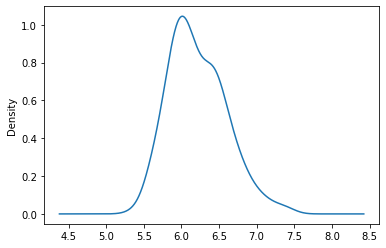

In [385]:
df['RM'].plot(kind='kde')

### 6.AGE

<AxesSubplot:ylabel='Density'>

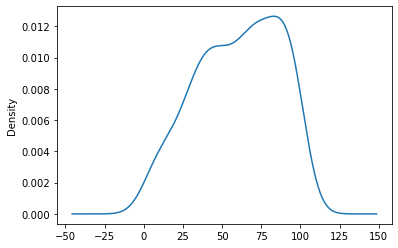

In [386]:
df['AGE'].plot(kind='kde')

In [387]:
from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(method='yeo-johnson')
df['AGE'] = transformer.fit_transform(df[['AGE']])


<AxesSubplot:ylabel='Density'>

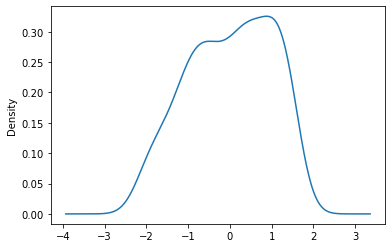

In [388]:
df['AGE'].plot(kind='kde')

### 7.DIS

<AxesSubplot:ylabel='Density'>

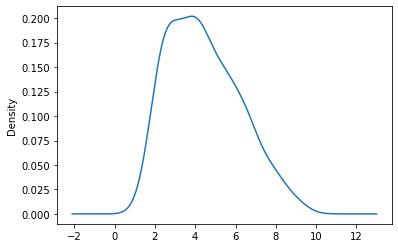

In [389]:
df['DIS'].plot(kind='kde')

<AxesSubplot:xlabel='DIS', ylabel='Density'>

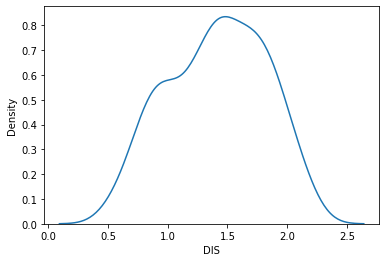

In [390]:
sns.kdeplot(np.log(df['DIS']))

### 8.RAD

<AxesSubplot:xlabel='RAD', ylabel='Density'>

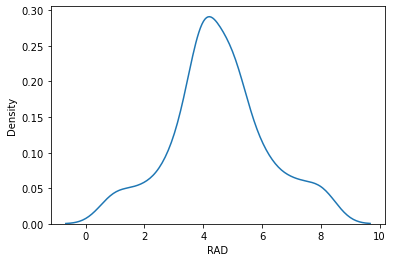

In [391]:
sns.kdeplot(df['RAD'])

### 9.TAX

<AxesSubplot:xlabel='TAX', ylabel='Density'>

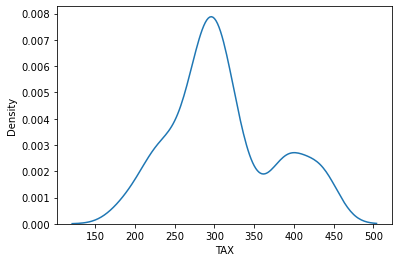

In [392]:
sns.kdeplot(df['TAX'])

### 10.PTRATIO

<AxesSubplot:xlabel='PTRATIO', ylabel='Density'>

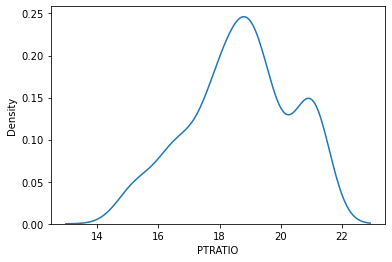

In [393]:
sns.kdeplot(df['PTRATIO'])

In [394]:
df['PTRATIO'] = transformer.fit_transform(df[['PTRATIO']])


<AxesSubplot:xlabel='PTRATIO', ylabel='Density'>

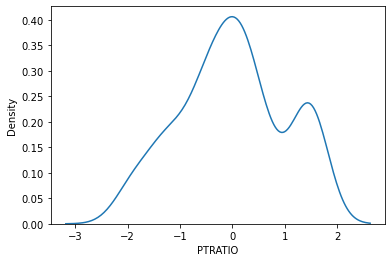

In [395]:
sns.kdeplot(df['PTRATIO'])

### 11.B

<AxesSubplot:xlabel='B', ylabel='Density'>

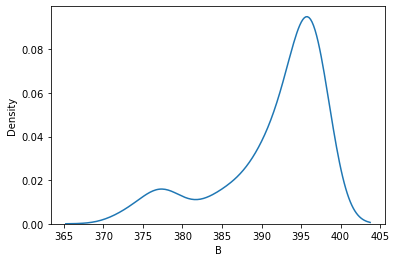

In [396]:
sns.kdeplot(df['B'])

<AxesSubplot:xlabel='B', ylabel='Density'>

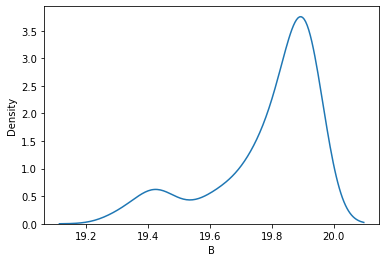

In [397]:
sns.kdeplot(np.sqrt(df['B']))

### 12.LSTAT

<AxesSubplot:xlabel='LSTAT', ylabel='Density'>

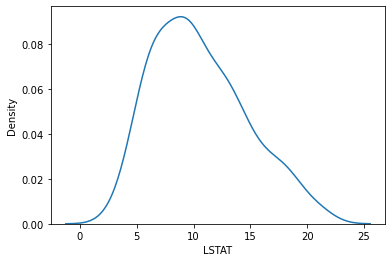

In [398]:
sns.kdeplot(df['LSTAT'])

In [399]:
x=df.drop(columns='house_price')
y=df['house_price']
y

0      24.0
1      21.6
5      28.7
6      22.9
7      27.1
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: house_price, Length: 214, dtype: float64

### train test split

In [400]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [401]:
x_train.shape

(171, 11)

In [402]:
x_test.shape

(43, 11)

In [403]:
y_train.shape

(171,)

In [404]:
y_test.shape

(43,)

### scaling data

In [405]:
scaler=StandardScaler()
scaled_x_train=scaler.fit_transform(x_train)
scaled_x_test=scaler.transform(x_test)

In [406]:
scaled_x_train

array([[-0.30965297,  0.01361759,  0.40779409, ...,  1.4406001 ,
         0.19962592,  0.44651729],
       [-0.30470663,  1.08589713, -1.03411462, ..., -1.46466958,
         0.81507147,  1.30052323],
       [ 1.09095823,  2.68031281,  2.21452308, ...,  1.65070099,
         0.81507147,  1.93798636],
       ...,
       [-0.29180462,  0.30369321,  0.87684874, ..., -0.5105109 ,
         0.02566387,  0.75794966],
       [ 0.42206019, -0.22244396, -0.06126055, ...,  0.57398454,
         0.81507147, -0.67999197],
       [ 3.33383169,  2.68031281,  2.21452308, ...,  1.65070099,
         0.81507147,  0.42948584]])

### Model training

In [407]:
lr=LinearRegression()
lr

LinearRegression()

In [408]:
lr.fit(scaled_x_train,y_train)

LinearRegression()

In [409]:
lr.coef_

array([ 1.39064694e-01, -3.01080710e-01, -2.64140364e-01,  2.35368842e+00,
       -1.19138886e+00, -1.25471911e+00,  5.64716327e-01, -7.31599550e-01,
       -9.98732700e-01, -1.46863180e-03, -3.59946287e-01])

In [410]:
lr.intercept_

22.274853801169595

### Model Evaluation

In [411]:
y_pred=lr.predict(scaled_x_test)


### Evaluation on testing data

In [412]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r_squared=r2_score(y_test,y_pred)
adj_r2=1-(((1-r_squared)*(x_test.shape[0]-1))/(x_test.shape[0]-x_test.shape[1]-1))
print(f'mse:{mse}')
print(f'mae:{mae}')
print(f'rmse:{rmse}')
print(f'r2_score:{r_squared}')
print(f'adj_r2:{adj_r2}')

mse:3.417572483893889
mae:1.3708044765087832
rmse:1.8486677591968463
r2_score:0.6888091336461546
adj_r2:0.5783865681657578


### feature selection

In [424]:
from sklearn.feature_selection import SelectFromModel
sfm=SelectFromModel(lr,threshold=0.5)
sfm.fit(scaled_x_train,y_train)
x_train=sfm.transform(scaled_x_train)
x_train
x_test=sfm.transform(scaled_x_test)
x_test.shape

(43, 6)

In [425]:
model=LinearRegression()
model

LinearRegression()

In [426]:
model.fit(x_train,y_train)

LinearRegression()

In [427]:
y_pred=model.predict(x_test)


In [428]:
x_train.shape

(171, 6)

In [429]:
x_test.shape

(43, 6)

In [430]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r_squared=r2_score(y_test,y_pred)
adj_r2=1-(((1-r_squared)*(x_test.shape[0]-1))/(x_test.shape[0]-x_test.shape[1]-1))
print(f'mse:{mse}')
print(f'mae:{mae}')
print(f'rmse:{rmse}')
print(f'r2_score:{r_squared}')
print(f'adj_r2:{adj_r2}')

mse:3.149829000595986
mae:1.3015393919272398
rmse:1.774775760651465
r2_score:0.7131888145221954
adj_r2:0.6653869502758947
